# QMC on Manifolds

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.stats
import time
import os
# import qmcpy as qp
import matplotlib
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
# import pandas as pd
# COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
# pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
COLORS = ["xkcd:purple","xkcd:blue","xkcd:green","xkcd:red","xkcd:orange","xkcd:cyan","xkcd:brown","xkcd:yellow"]
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
DEFAULTFONTSIZE = 30
pyplot.rcParams['xtick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['axes.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams['figure.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams["axes.labelsize"] = DEFAULTFONTSIZE
pyplot.rcParams['legend.fontsize'] = DEFAULTFONTSIZE
pyplot.rcParams['font.size'] = DEFAULTFONTSIZE
pyplot.rcParams['lines.linewidth'] = 5
pyplot.rcParams['lines.markersize'] = 15
PW = 30 # inches

## Sphere

In [19]:
class KernelSphereA(object):
    def __init__(self):
        self.integral = 2/3
    def __call__(self, x, y):
        return 2-torch.linalg.norm(x-y,dim=-1)
class KernelShereB(object):
    def __init__(self):
        self.integral = 1-np.exp(-48)
    def __call__(self, x, y):
        return 48*torch.exp(-12*torch.linalg.norm(x-y,dim=-1)**2)
def unif_to_S2(x):
    assert x.size(-1)==2
    t = torch.sqrt(x[:,1]-x[:,1]**2)
    y = torch.stack([
        2*torch.cos(2*np.pi*x[:,0])*t,
        2*torch.sin(2*np.pi*x[:,0])*t,
        1-2*x[:,1]
        ],axis=-1)
    return y

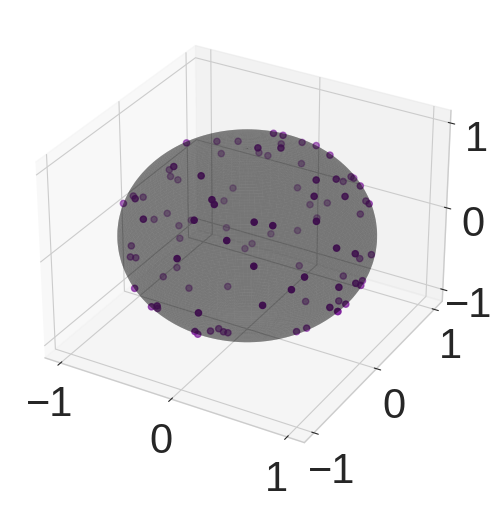

In [30]:
def get_spheres_fig_ax(nrows=1,ncols=1,axisoff=False,figwidth=PW):
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(figwidth,figwidth/ncols*nrows),subplot_kw={"projection":"3d"})
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    phimesh,thetamesh = torch.meshgrid(torch.linspace(0,np.pi,100),torch.linspace(0,2*np.pi,100),indexing="ij")
    xmesh = torch.sin(phimesh)*torch.cos(thetamesh)
    ymesh = torch.sin(phimesh)*torch.sin(thetamesh)
    zmesh = torch.cos(phimesh)
    for i in range(nrows):
        for j in range(ncols):
            ax[i,j].plot_surface(xmesh,ymesh,zmesh,rstride=1,cstride=1,color='k',alpha=0.3,linewidth=0)
            if axisoff:
                ax[i,j].axis("off");
    return fig,ax
fig,ax = get_spheres_fig_ax(figwidth=PW/5)
rng = torch.Generator().manual_seed(17)
n = 100
x_iid = unif_to_S2(torch.rand(n,2,generator=rng))
ax[0,0].scatter(x_iid[:,0],x_iid[:,1],x_iid[:,2],color=COLORS[0]);